## Setup

In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))


from src.phrase_analysis import process_directory, plot_phrase_frequency_over_time_all, plot_length_distribution, analyze_files_phrase_occurrences, get_recent_contexts, get_recent_contexts_all, get_per_appearance_frequency, get_phrases, count_phrases
from src.regex_pattern_generator import generate_regex_patterns
from datetime import datetime
import pandas as pd

In [4]:
INAUGURATION_DATE = datetime(2025, 1, 20)
CONTEXT_WINDOW = 200 # words to display for context

In [5]:
PHRASES = get_phrases("KXTRUMPSAYTRUMP-26JUL01")
PHRASES = [phrase if phrase != "Whack Job" else "Whack Job / wack job / wackjob / whackjob" for phrase in PHRASES]
PHRASES = [phrase if phrase != "Third Term" else "Third term / 3rd term" for phrase in PHRASES]
PHRASES = [phrase if phrase != "Crying Chuck / Cryin Chuck" else "Crying Chuck / Cryin Chuck / Cryin' Chuck" for phrase in PHRASES]
PHRASES = [phrase if phrase != "Marjorie Traitor Greene" else "Marjorie Traitor Greene / Marjorie 'Traitor' Greene / Marjorie \"Traitor\" Greene" for phrase in PHRASES]
SEARCH_PHRASES = generate_regex_patterns(PHRASES)

from pprint import pprint
pprint(SEARCH_PHRASES)

{'Fort Trump': "\\b(?:\\w+-)*(?:fort[\\s,\\-]+trump|fort[\\s,\\-]+trumps|fort[\\s,\\-]+trump's|fort[\\s,\\-]+trumps'|forts[\\s,\\-]+trump|forts[\\s,\\-]+trumps|forts[\\s,\\-]+trump's|forts[\\s,\\-]+trumps'|fort's[\\s,\\-]+trump|fort's[\\s,\\-]+trumps|fort's[\\s,\\-]+trump's|fort's[\\s,\\-]+trumps'|forts'[\\s,\\-]+trump|forts'[\\s,\\-]+trumps|forts'[\\s,\\-]+trump's|forts'[\\s,\\-]+trumps')(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Gulf of Trump': "\\b(?:\\w+-)*(?:gulf[\\s,\\-]+of[\\s,\\-]+trump|gulf[\\s,\\-]+of[\\s,\\-]+trumps|gulf[\\s,\\-]+of[\\s,\\-]+trump's|gulf[\\s,\\-]+of[\\s,\\-]+trumps'|gulf[\\s,\\-]+ofs[\\s,\\-]+trump|gulf[\\s,\\-]+ofs[\\s,\\-]+trumps|gulf[\\s,\\-]+ofs[\\s,\\-]+trump's|gulf[\\s,\\-]+ofs[\\s,\\-]+trumps'|gulf[\\s,\\-]+of's[\\s,\\-]+trump|gulf[\\s,\\-]+of's[\\s,\\-]+trumps|gulf[\\s,\\-]+of's[\\s,\\-]+trump's|gulf[\\s,\\-]+of's[\\s,\\-]+trumps'|gulf[\\s,\\-]+ofs'[\\s,\\-]+trump|gulf[\\s,\\-]+ofs'[\\s,\\-]+trumps|gulf[\\s,\\-]+ofs'[\\s,\\-]+trump's|gulf[\\s,\\-]+ofs'[\\s,\\-

In [7]:
# Truth Social posts processing (separate 'truth' category)
from IPython.display import display
import re

TRUTH_CSV = "/Users/jstenger/Documents/repos/trading/kalshi-research/data/truth-social/trump_truths_full.csv"

# Load merged Truth Social dataset (created by src/parse_truth_rtf_and_merge.py)
truth_df_raw = pd.read_csv(TRUTH_CSV, dtype=str)

# Normalize columns
truth_df_raw["post_date"] = pd.to_datetime(truth_df_raw["post_date"], errors="coerce")
truth_df_raw = truth_df_raw.dropna(subset=["post_date"]).copy()
truth_df_raw["status_text"] = truth_df_raw["status_text"].fillna("").astype(str)

# Remove anything including and after 'RT @...' and remove all URLs starting with https://
deleted_posts = []
cleaned_truth_records = []

for idx, row in truth_df_raw.iterrows():
    text = row["status_text"]
    # Remove all URLs starting with https://
    text = re.sub(r'https://\S+', '', text)
    # Find 'RT @' (case-insensitive)
    rt_match = re.search(r'RT\s*@', text, re.IGNORECASE)
    if rt_match:
        if rt_match.start() == 0:
            # If 'RT @' is at the beginning, remove the entire post
            deleted_posts.append({
                "date": row["post_date"],
                "text": text
            })
            continue
        else:
            # Otherwise, remove everything from 'RT @' onward
            text = text[:rt_match.start()].rstrip()
    if not text.strip():
        # If text is empty after cleaning, treat as deleted
        deleted_posts.append({
            "date": row["post_date"],
            "text": row["status_text"]
        })
        continue
    counts = count_phrases(text, SEARCH_PHRASES)
    cleaned_truth_records.append({
        "date": row["post_date"],
        "file": None,
        "category": "truth",
        "text_length": len(text.split()),
        "text": text,
        **counts
    })

truth_df = pd.DataFrame(cleaned_truth_records).sort_values("date").reset_index(drop=True)

# Print out deleted posts
print(f"Deleted {len(deleted_posts)} posts due to 'RT @' at start or empty after cleaning.")
if deleted_posts:
    print("Sample deleted posts:")
    for i, post in enumerate(deleted_posts[:5]):
        print(f"{i+1}. Date: {post['date']}, Text: {post['text'][:100]}{'...' if len(post['text'])>100 else ''}")

# Preview
display(truth_df.head(1))
print(f"Truth posts processed: {len(truth_df)}")

Deleted 0 posts due to 'RT @' at start or empty after cleaning.


,date,file,category,text_length,text,Trump Dollar / Trump Bill,Trump Kennedy Center,TrumpRX,Trump Account,Trump Card,Gulf of Trump,Trump National / Trump International,Mount Trump,Trump Strait / Strait of Trump,Trump University,Fort Trump,Trump Arc / Arc de Trump,Trump Airport,Trump Tower
0,2024-05-22 23:04:00,None,truth,1,Tickets:,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Truth posts processed: 7572


In [8]:
import pandas as pd
# Set the category of interest

# Process transcripts
df_transcripts = process_directory('../../data/processed-transcripts', SEARCH_PHRASES)
df_transcripts = df_transcripts[df_transcripts['category'] != 'press briefing']
df_transcripts = df_transcripts.sort_values('date')

Found 4182 .txt files to process with 14 patterns...
  Processed 500/4182 files... (current: remarks/2025-12-04_donald_trump_participates_in_lighting_t)
  Processed 1000/4182 files... (current: remarks/2020-03-17_donald_trump_meets_with_tourism_executi)
  Processed 1500/4182 files... (current: remarks/2025-11-07_donald_trump_holds_a_bilateral_meeting_)
  Processed 2000/4182 files... (current: press conference/2020-04-17_donald_trump_holds_the_daily_coronaviru)
  Processed 2500/4182 files... (current: speech/2018-08-31_donald_trump_signs_a_retirement_savings)
  Processed 3000/4182 files... (current: interview/2025-04-25_time_magazine_conducts_an_interview_wit)
  Processed 3500/4182 files... (current: interview/2020-12-20_donald_trump_calls_in_to_uncovering_the)
  Processed 4000/4182 files... (current: press gaggle/2019-08-30_donald_trump_speaks_to_the_press_before)

Completed processing 4182 files.
Categories found in directory:
- 60 minutes story
- convention
- court transcript
- debat

In [9]:
CATEGORY_OF_INTEREST = "truth"

df = pd.concat([df_transcripts, truth_df], ignore_index=True).sort_values('date').reset_index(drop=True) # kalshi rules
# df = df_transcripts # polymarket rules
print(f"Combined dataset size: {len(df)} records")
df_category = df[df['category'] == CATEGORY_OF_INTEREST]
df_non_category =  df[df['category'] != CATEGORY_OF_INTEREST]

Combined dataset size: 11653 records


## Phrase Frequency Over Time

Speeches dropped off dramatically between election day and inauguration day. Non-speech transcripts mostly don't go back as far in time (need to scrape more data)


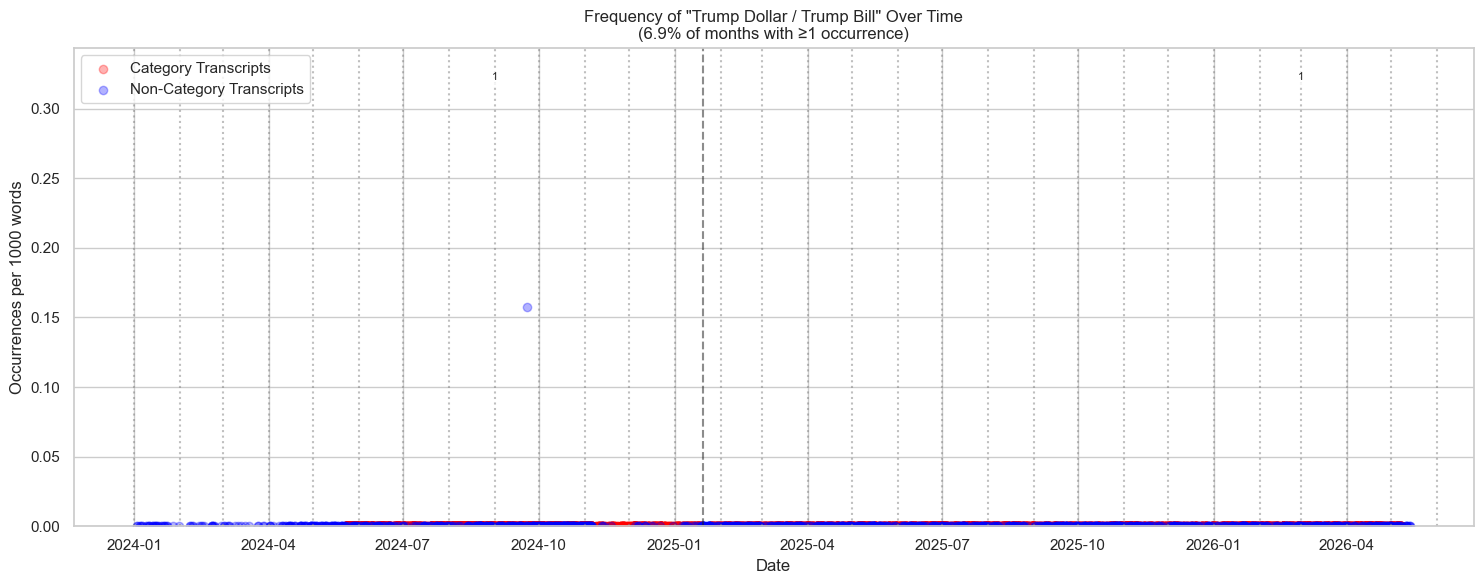


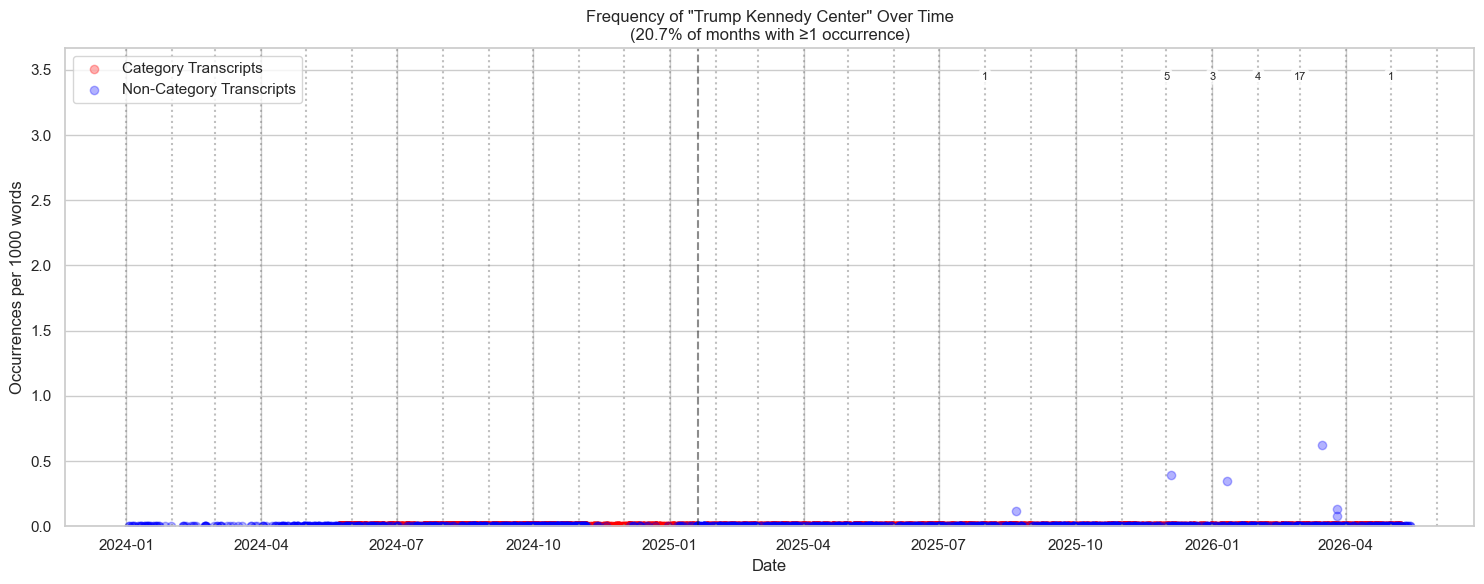


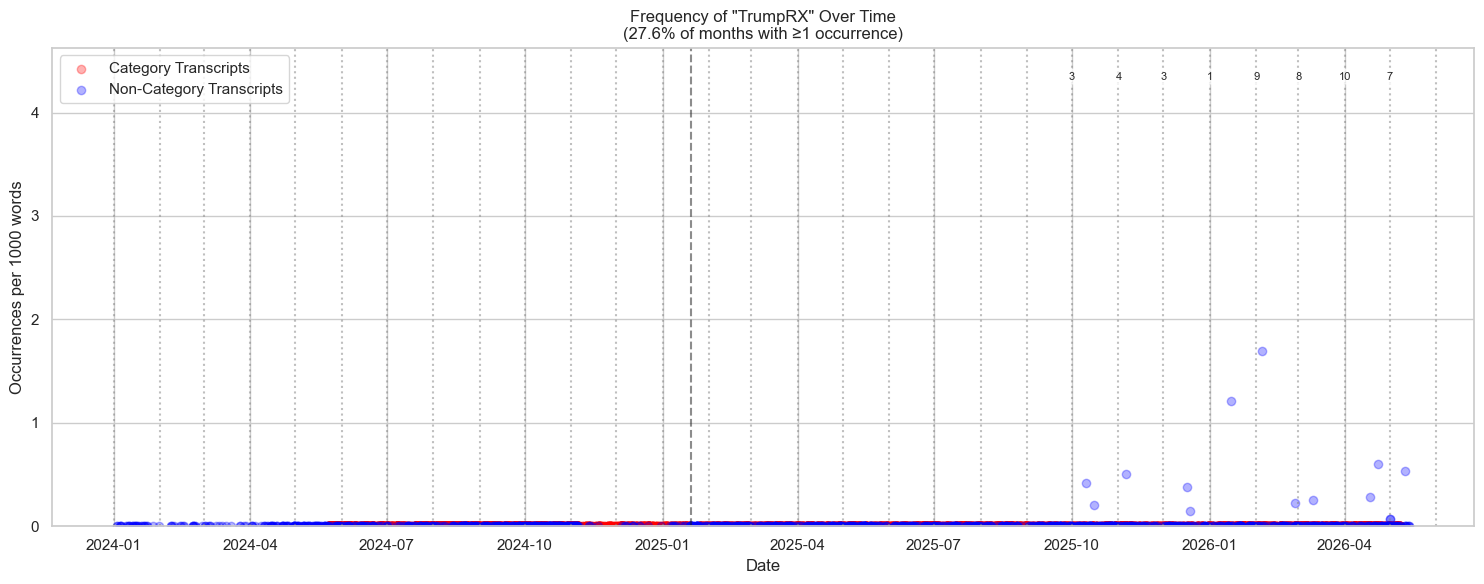


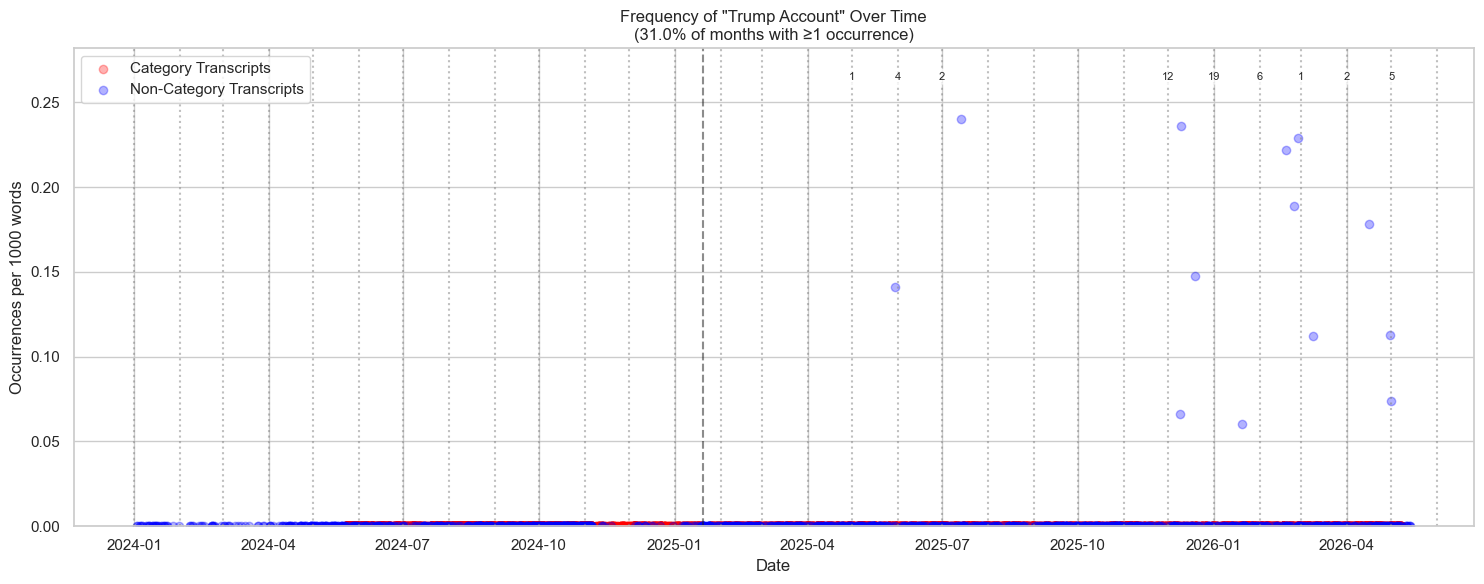


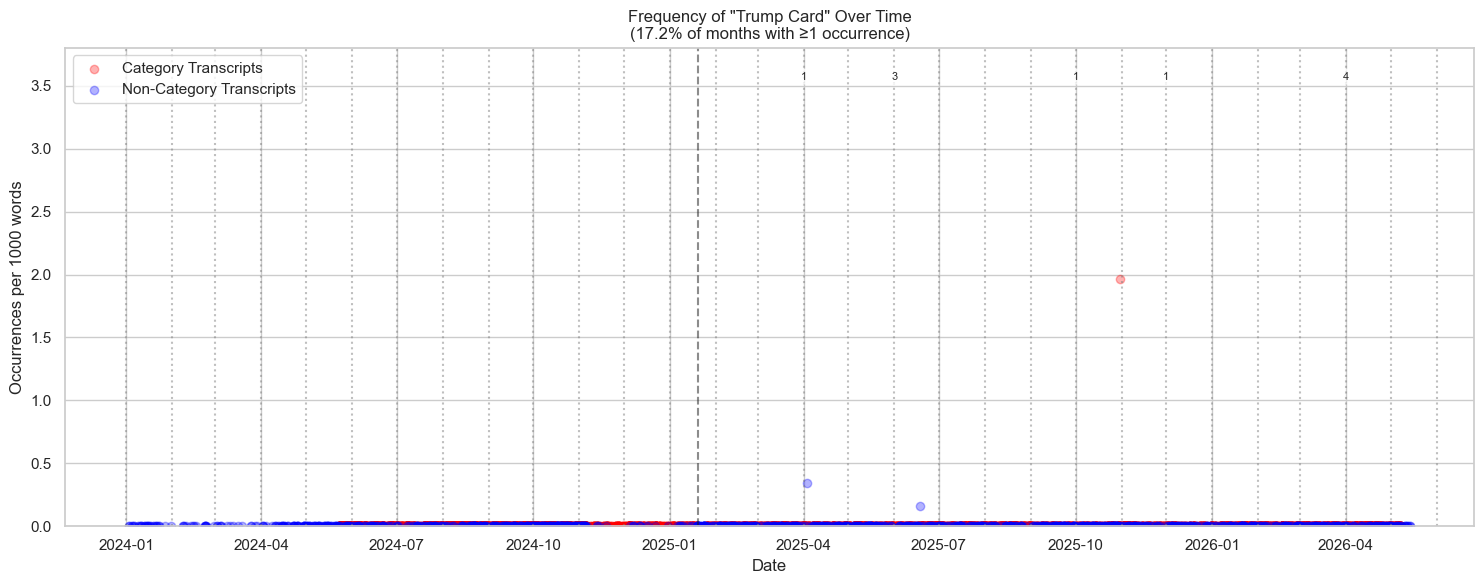


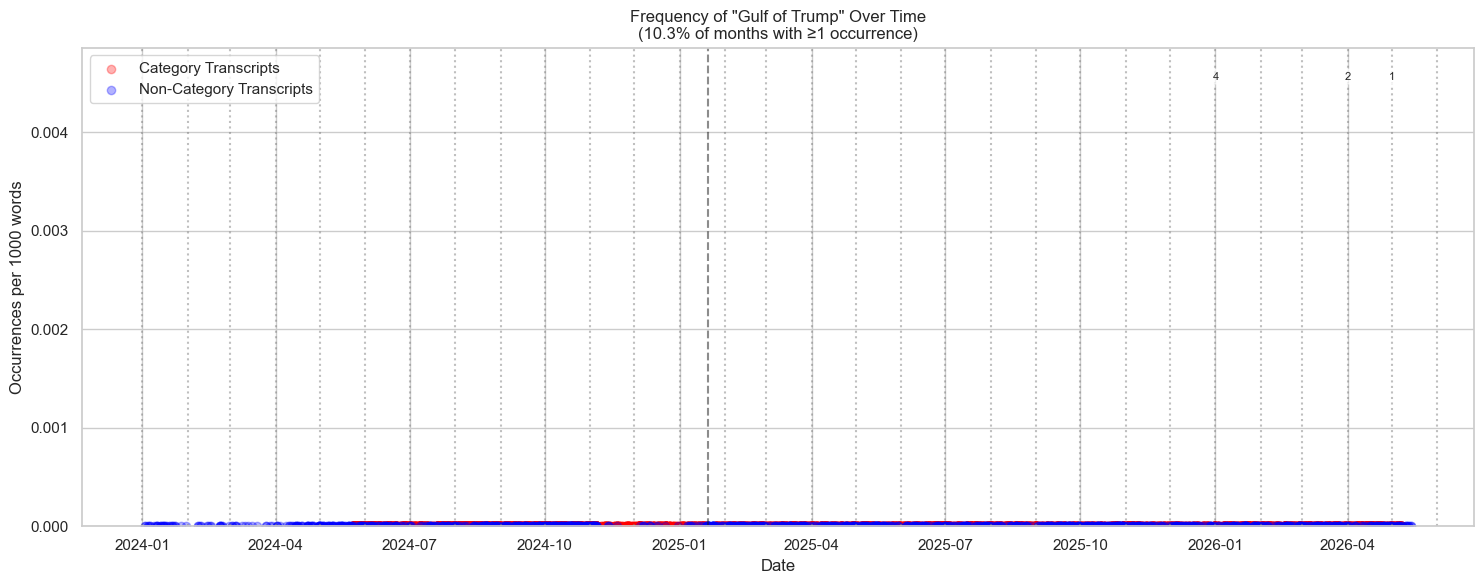


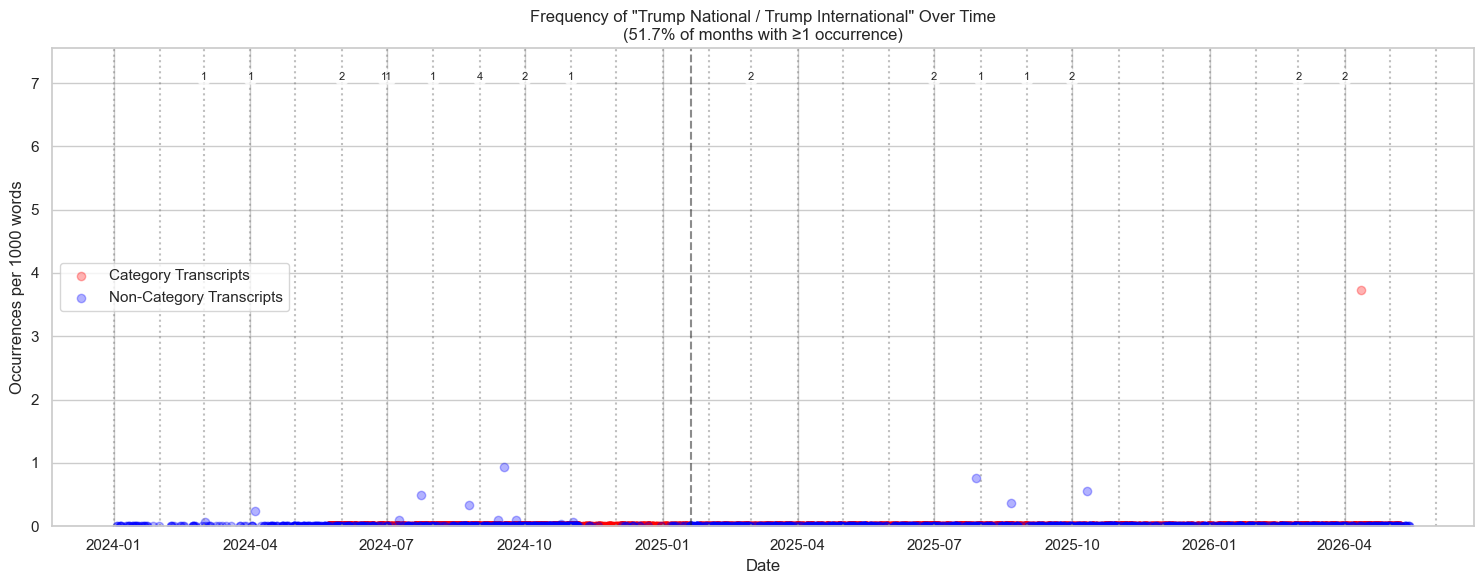

/Users/jstenger/Documents/repos/trading/kalshi-research/src/phrase_analysis.py:500: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(0, ymax)



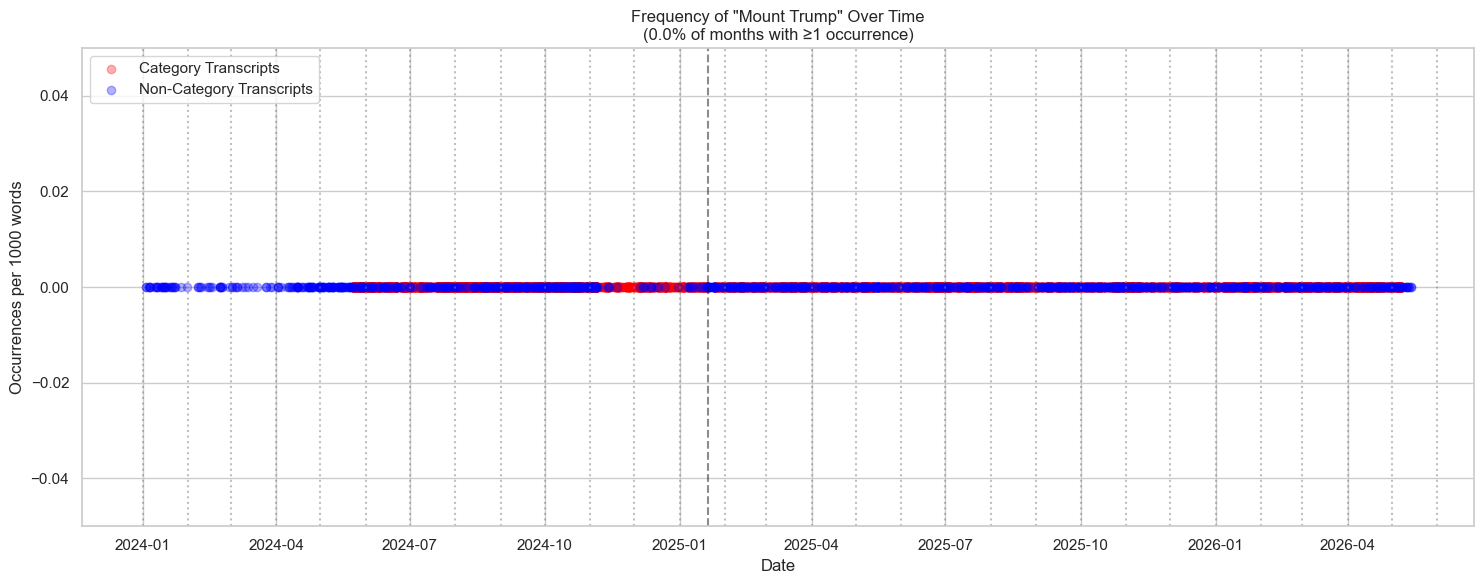


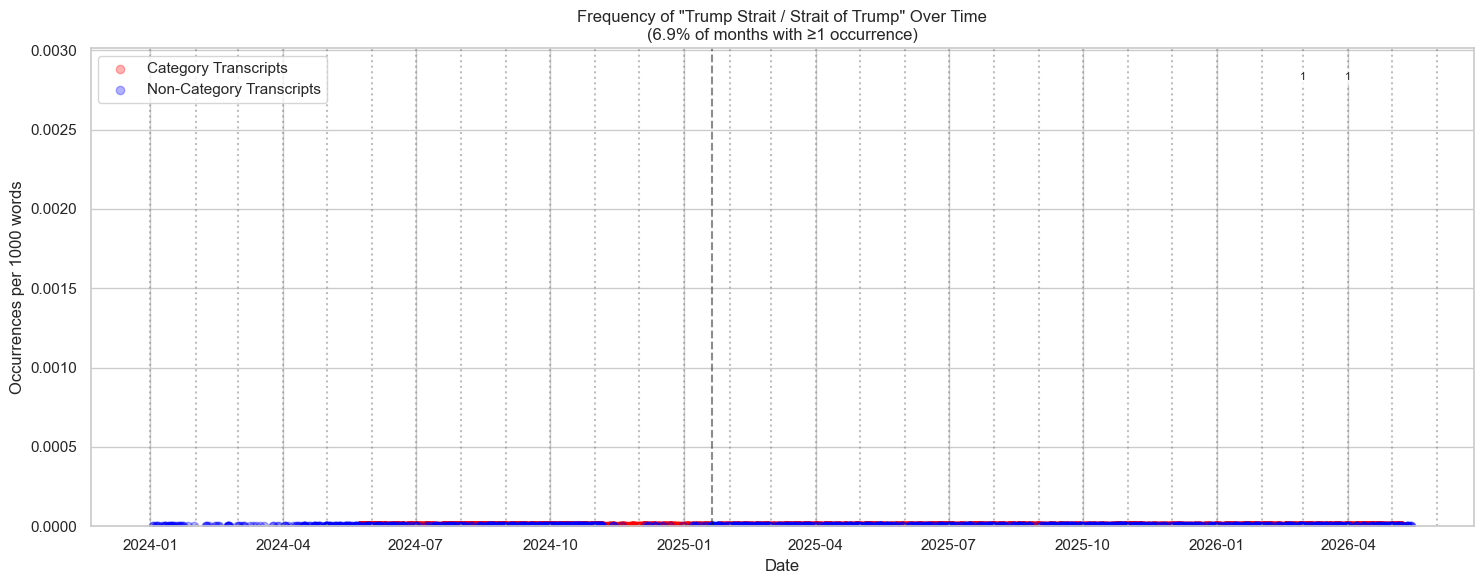


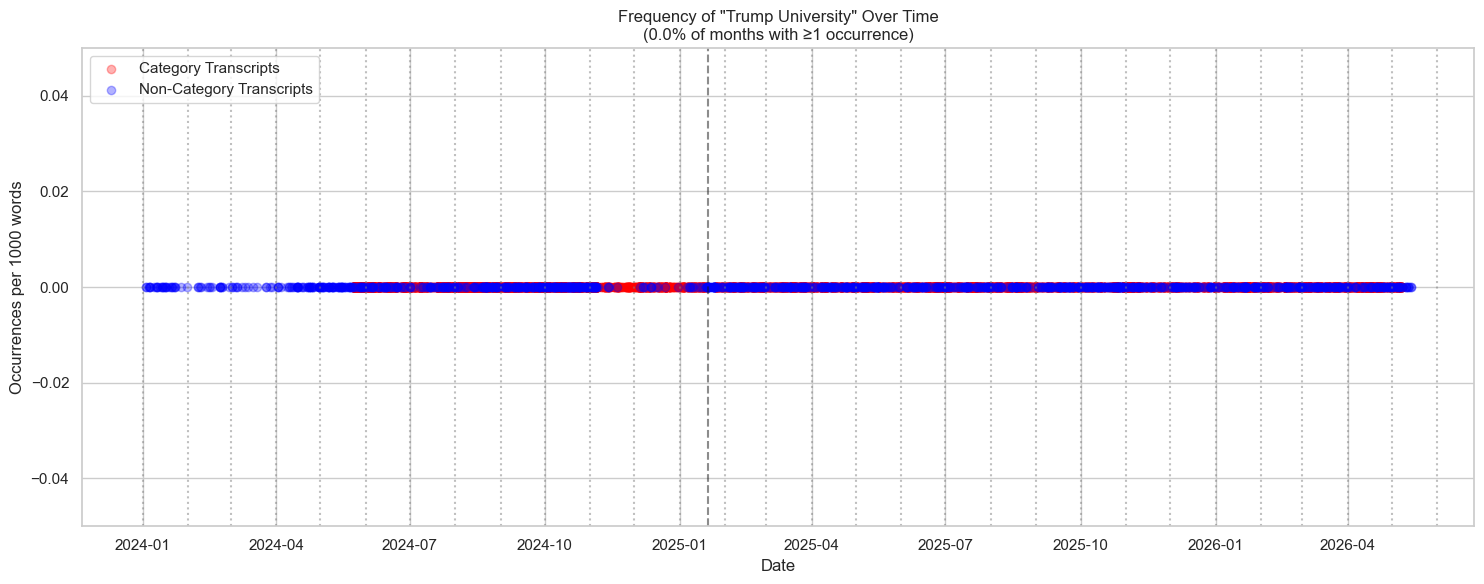


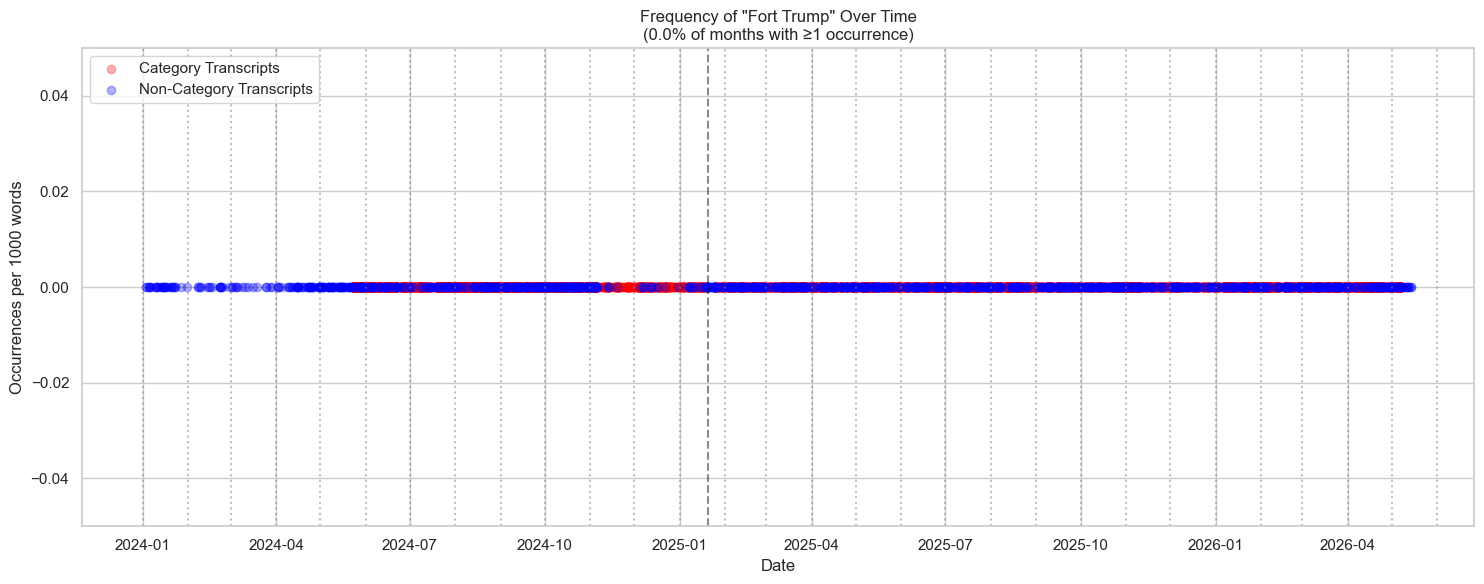


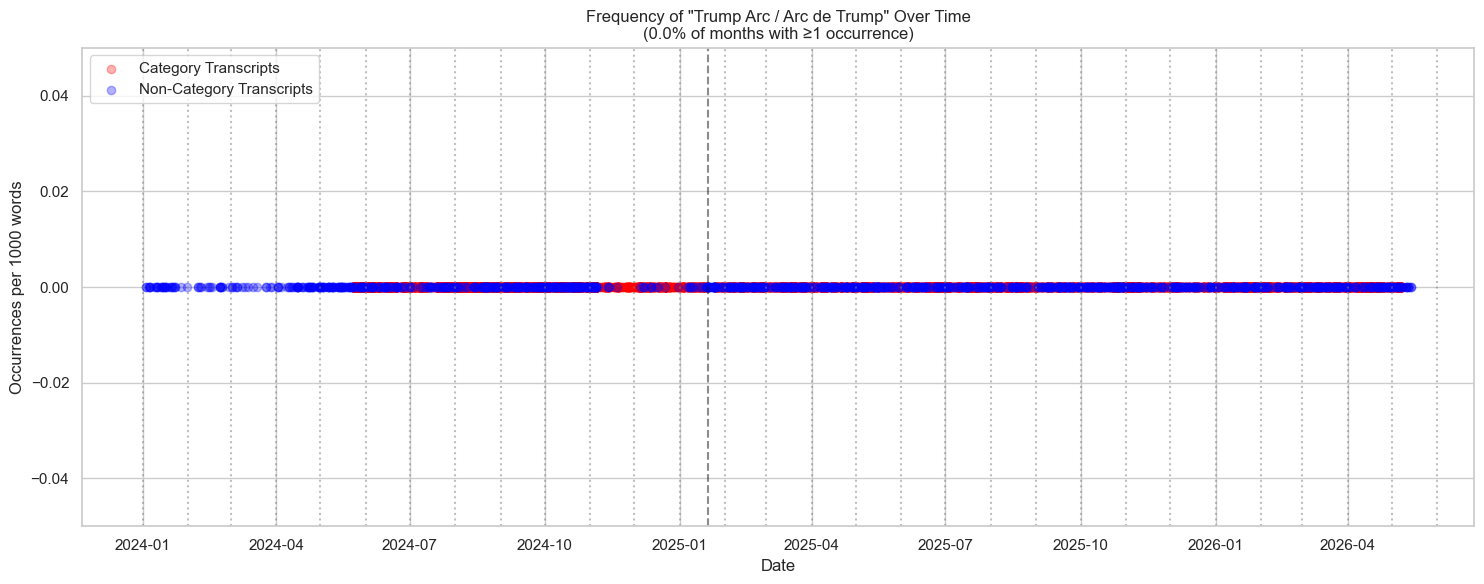


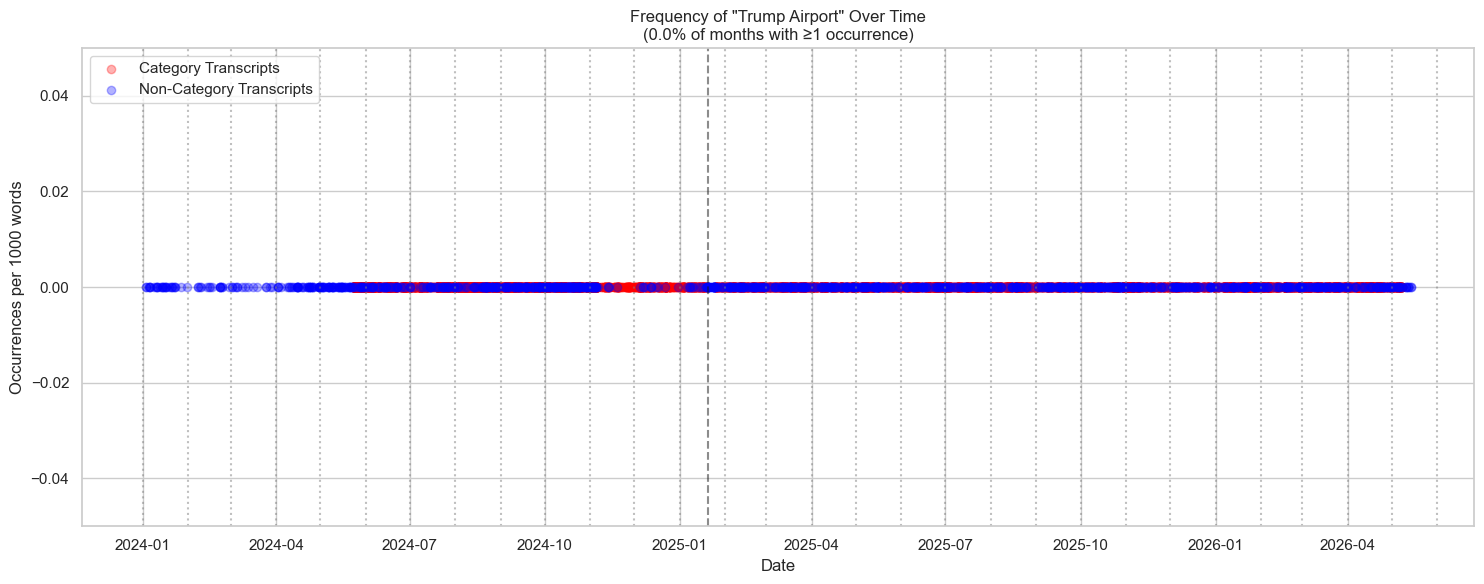


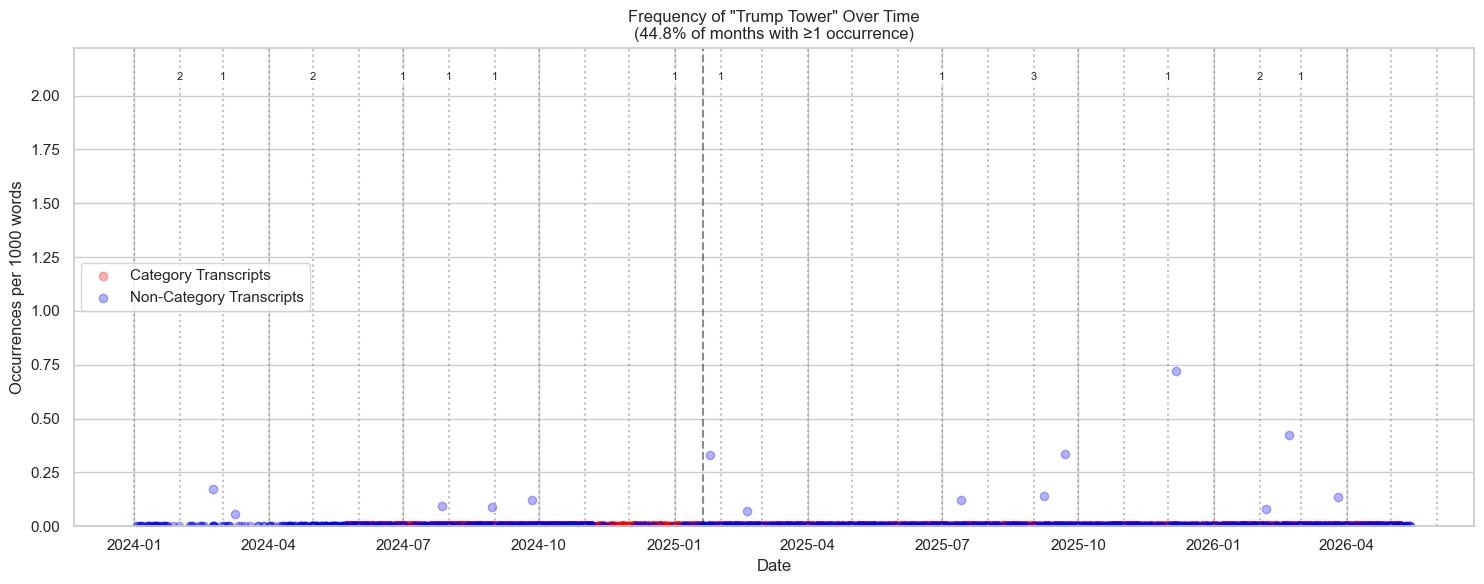

In [10]:
plot_phrase_frequency_over_time_all(df_category, df_non_category, start_date=datetime(2024, 1, 1), show_monthly_grid=True, show_moving_average=False, phrases=SEARCH_PHRASES, window=100)

## Recent Usage in context

In [11]:
get_recent_contexts_all(df, SEARCH_PHRASES, n=10)


=== Recent usage of 'Trump Dollar / Trump Bill' ===

Title: nan
Date: 2026-03-06 (truth)
Context: ...s Bill Maher as a ‘Highly Overrated Lightweight’ and Calls Their White House Dinner a ‘Complete Waste of Time’: ‘He Is No Different Than Kimmel, Fallon, or Colbert’: https:// variety.com/2026/tv/news/trump -bill-maher-white-house-dinner-waste-of-time-1236663505/

Title: 2024-09-23_donald_trump_speaks_at_farming_roundtable_in_smithton_pennsylvania.txt
Date: 2024-09-23 (remarks)
Context: ...ad panels, but they're sending them over, and they are really putting a lot of people out of work. But that's an amazing issue. It's a form of subsidy.

By the way, the death tax, as you know, in the Trump bill, you don't have to pay a death tax or a inheritance tax. And under them, they want that terminated. They want you to pay. And what happens especially with farmers, you're sort of land rich but cash po...


=== Recent usage of 'Trump Kennedy Center' ===

Title: nan
Date: 2026-05-04 (truth)
Conte

## Probability Modeling: Will Trump say a word this month?

Given we're `d` days into a month, what's the probability Trump will say a specific word in the remaining days?


In [ ]:
import numpy as np
from scipy import stats
from datetime import datetime, timedelta
import calendar

# Parameters
# Set CURRENT_MONTH to the most recent month available in the data programmatically
if not df.empty:
    latest_date = df['date'].max()
    CURRENT_MONTH = datetime(latest_date.year, latest_date.month, 1)
else:
    CURRENT_MONTH = datetime(datetime.now().year, datetime.now().month, 1)

DAYS_IN_MONTH = calendar.monthrange(CURRENT_MONTH.year, CURRENT_MONTH.month)[1]

# Use the actual current day
CURRENT_DAY = datetime.now().day

# Analysis period for historical data (post-inauguration)
ANALYSIS_START = datetime(2024, 1, 1)
ANALYSIS_END = df['date'].max() if not df.empty else datetime.now()


In [ ]:
def calculate_monthly_stats(df, category_filter=None):
    """
    Calculate monthly statistics for each phrase.
    Returns DataFrame with columns: phrase, months_appeared, total_months, monthly_rate, avg_count_when_appeared
    """
    # Filter data
    df_filtered = df.copy()
    if category_filter:
        df_filtered = df_filtered[df_filtered['category'] == category_filter]
    
    # Filter to analysis period
    df_filtered = df_filtered[
        (df_filtered['date'] >= ANALYSIS_START) & 
        (df_filtered['date'] <= ANALYSIS_END)
    ]
    
    # Add month column
    df_filtered['month'] = df_filtered['date'].dt.to_period('M')
    
    # Get all phrases (columns that are not metadata)
    metadata_cols = ['date', 'file', 'category', 'text_length', 'text', 'month']
    phrase_cols = [col for col in df_filtered.columns if col not in metadata_cols]
    
    stats_list = []
    total_months = df_filtered['month'].nunique()
    
    for phrase in phrase_cols:
        # Group by month and sum occurrences
        monthly_counts = df_filtered.groupby('month')[phrase].sum()
        
        # Months where phrase appeared at least once
        months_appeared = (monthly_counts > 0).sum()
        
        # Average count when it did appear
        avg_count = monthly_counts[monthly_counts > 0].mean() if months_appeared > 0 else 0
        
        stats_list.append({
            'phrase': phrase,
            'months_appeared': months_appeared,
            'total_months': total_months,
            'monthly_rate': months_appeared / total_months if total_months > 0 else 0,
            'avg_count_when_appeared': avg_count,
            'total_occurrences': monthly_counts.sum()
        })
    
    return pd.DataFrame(stats_list).sort_values('monthly_rate', ascending=False)

# Calculate stats for the category of interest
monthly_stats = calculate_monthly_stats(df)
display(monthly_stats)


,phrase,months_appeared,total_months,monthly_rate,avg_count_when_appeared,total_occurrences
5,Transgender,25,25,1.00,13.000000,325
21,DEI / Woke,24,25,0.96,17.583333,422
9,Sleepy Joe,24,25,0.96,9.750000,234
10,Predict / Prediction,24,25,0.96,2.583333,62
11,Pelosi,23,25,0.92,7.304348,168
0,Windmill,22,25,0.88,8.090909,178
4,Trump Derangement Syndrome,21,25,0.84,4.095238,86
23,Barack Hussein Obama,20,25,0.80,8.100000,162
14,Newscum,20,25,0.80,4.850000,97
22,Crypto / Bitcoin,19,25,0.76,16.000000,304


### Approach 1: Poisson Process Model

Assumes word occurrences follow a Poisson process with constant rate λ throughout the month.

For a word with monthly appearance rate `p` and average count `μ` when it appears:
- Daily rate: λ ≈ p × μ / days_in_month
- P(haven't said by day d | will say this month) = e^(-λd)
- P(will say in remaining days | haven't said yet) = 1 - e^(-λ(D-d))


In [ ]:
def poisson_probability(monthly_rate, avg_count, days_elapsed, days_in_month):
    """
    Calculate probability using Poisson process model.
    
    Args:
        monthly_rate: Historical probability word appears in a month
        avg_count: Average number of times word appears when it does appear
        days_elapsed: Number of days that have passed in current month
        days_in_month: Total days in the month
    
    Returns:
        Dictionary with probabilities
    """
    # Daily occurrence rate (expected occurrences per day)
    lambda_daily = (monthly_rate * avg_count) / days_in_month
    
    # Probability of at least one occurrence in remaining days
    days_remaining = days_in_month - days_elapsed
    p_occurrence_remaining = 1 - np.exp(-lambda_daily * days_remaining)
    
    # Probability we haven't seen it yet (given it will appear)
    # This is for Bayesian updating: if we haven't seen it, does that change our belief?
    p_not_yet_seen = np.exp(-lambda_daily * days_elapsed)
    
    # Bayesian update: P(will appear | haven't seen yet)
    # Using Bayes: posterior = likelihood × prior / evidence
    # If monthly_rate is very low, not seeing it yet doesn't change much
    # If monthly_rate is high, not seeing it yet reduces probability
    
    # Simple approach: condition on not seeing it yet
    # P(appears in month) = monthly_rate
    # P(appears in remaining days | not yet seen) = monthly_rate × P(in remaining days | in month) / P(not yet seen | will appear in month)
    
    # Simpler: just use the rate for remaining time, don't update based on not seeing it
    # This assumes no intra-month pattern
    p_remaining_simple = 1 - np.exp(-lambda_daily * days_remaining)
    
    # Alternative: Bayesian update
    # Prior: monthly_rate chance of appearing this month
    # Evidence: we haven't seen it in first d days
    # P(not seen in first d days) = P(won't appear at all) + P(will appear but not in first d days)
    p_wont_appear = 1 - monthly_rate
    p_appears_but_not_yet = monthly_rate * p_not_yet_seen
    p_not_seen_yet = p_wont_appear + p_appears_but_not_yet
    
    # Posterior: P(will appear | not seen yet)
    p_will_appear_given_not_seen = p_appears_but_not_yet / p_not_seen_yet if p_not_seen_yet > 0 else 0
    
    # Of those cases where it will appear, probability it's in remaining days
    p_in_remaining_given_appears = 1 - np.exp(-lambda_daily * days_remaining) / (1 - np.exp(-lambda_daily * days_in_month))
    
    # Combined Bayesian probability
    p_remaining_bayesian = p_will_appear_given_not_seen * p_in_remaining_given_appears
    
    return {
        'lambda_daily': lambda_daily,
        'p_remaining_simple': p_remaining_simple,
        'p_remaining_bayesian': p_remaining_bayesian,
        'p_not_yet_seen_given_appears': p_not_yet_seen,
        'p_will_appear_given_not_seen': p_will_appear_given_not_seen
    }

# Test with a few examples
print("\\n=== POISSON MODEL PROBABILITIES ===\\n")
print(f"Current scenario: Day {CURRENT_DAY} of {DAYS_IN_MONTH} in {CURRENT_MONTH.strftime('%B %Y')}\\n")

test_phrases = monthly_stats.head(10)
for _, row in test_phrases.iterrows():
    probs = poisson_probability(
        row['monthly_rate'], 
        row['avg_count_when_appeared'],
        CURRENT_DAY,
        DAYS_IN_MONTH
    )
    
    print(f"{row['phrase']}:")
    print(f"  Historical: {row['monthly_rate']:.1%} of months, avg {row['avg_count_when_appeared']:.1f} times when appears")
    print(f"  λ (daily rate): {probs['lambda_daily']:.4f}")
    print(f"  P(says in remaining days | simple): {probs['p_remaining_simple']:.1%}")
    print(f"  P(says in remaining days | Bayesian update): {probs['p_remaining_bayesian']:.1%}")
    print()


\n=== POISSON MODEL PROBABILITIES ===\n
Current scenario: Day 13 of 31 in January 2026\n
Transgender:
  Historical: 100.0% of months, avg 13.0 times when appears
  λ (daily rate): 0.4194
  P(says in remaining days | simple): 99.9%
  P(says in remaining days | Bayesian update): 99.9%

DEI / Woke:
  Historical: 96.0% of months, avg 17.6 times when appears
  λ (daily rate): 0.5445
  P(says in remaining days | simple): 100.0%
  P(says in remaining days | Bayesian update): 2.0%

Sleepy Joe:
  Historical: 96.0% of months, avg 9.8 times when appears
  λ (daily rate): 0.3019
  P(says in remaining days | simple): 99.6%
  P(says in remaining days | Bayesian update): 32.0%

Predict / Prediction:
  Historical: 96.0% of months, avg 2.6 times when appears
  λ (daily rate): 0.0800
  P(says in remaining days | simple): 76.3%
  P(says in remaining days | Bayesian update): 66.3%

Pelosi:
  Historical: 92.0% of months, avg 7.3 times when appears
  λ (daily rate): 0.2168
  P(says in remaining days | simpl

### Approach 2: Binomial Model (Activity-Based)

Instead of modeling by days, model by "appearances" (speeches, Truth Social posts, etc.).

This is useful because Trump's activity varies - he might have 5 speeches in one day, none the next.


In [ ]:
def calculate_appearance_stats(df, category_filter=None):
    """
    Calculate statistics based on appearances (speeches, posts, etc.) rather than days.
    """
    # Filter data
    df_filtered = df.copy()
    if category_filter:
        df_filtered = df_filtered[df_filtered['category'] == category_filter]
    
    # Filter to analysis period
    df_filtered = df_filtered[
        (df_filtered['date'] >= ANALYSIS_START) & 
        (df_filtered['date'] <= ANALYSIS_END)
    ]
    
    # Add month column
    df_filtered['month'] = df_filtered['date'].dt.to_period('M')
    
    # Get phrase columns
    metadata_cols = ['date', 'file', 'category', 'text_length', 'text', 'month']
    phrase_cols = [col for col in df_filtered.columns if col not in metadata_cols]
    
    # Calculate appearances per month
    appearances_per_month = df_filtered.groupby('month').size()
    avg_appearances_per_month = appearances_per_month.mean()
    
    stats_list = []
    
    for phrase in phrase_cols:
        # For each month, count appearances where phrase was used
        monthly_appearances_with_phrase = df_filtered[df_filtered[phrase] > 0].groupby('month').size()
        
        # Months where phrase appeared
        months_appeared = len(monthly_appearances_with_phrase)
        total_months = df_filtered['month'].nunique()
        
        # Average appearances per month where it was used
        avg_appearances_with_phrase = monthly_appearances_with_phrase.mean() if months_appeared > 0 else 0
        
        # Probability per appearance (when it does appear in a month)
        if months_appeared > 0:
            # Get months where phrase appeared
            months_with_phrase = monthly_appearances_with_phrase.index
            total_appearances_in_those_months = appearances_per_month[months_with_phrase].sum()
            p_per_appearance = avg_appearances_with_phrase * months_appeared / total_appearances_in_those_months if total_appearances_in_those_months > 0 else 0
        else:
            p_per_appearance = 0
        
        stats_list.append({
            'phrase': phrase,
            'monthly_rate': months_appeared / total_months,
            'avg_appearances_per_month': avg_appearances_per_month,
            'p_per_appearance': p_per_appearance
        })
    
    return pd.DataFrame(stats_list), avg_appearances_per_month

appearance_stats, avg_appearances = calculate_appearance_stats(df)
print(f"\\nAverage appearances per month: {avg_appearances:.1f}\\n")
display(appearance_stats.head(20))


\nAverage appearances per month: 291.0\n


,phrase,monthly_rate,avg_appearances_per_month,p_per_appearance
0,Windmill,0.88,291.04,0.010723
1,UFC,0.64,291.04,0.009701
2,Turning Point,0.44,291.04,0.005581
3,TrumpRX / TrumpRX.gov,0.12,291.04,0.005325
4,Trump Derangement Syndrome,0.84,291.04,0.011292
5,Transgender,1.00,291.04,0.031611
6,Third term / 3rd term,0.12,291.04,0.004024
7,Taylor Swift,0.24,291.04,0.004963
8,Stimulus,0.04,291.04,0.001603
9,Sleepy Joe,0.96,291.04,0.020994


In [ ]:
def binomial_probability(monthly_rate, p_per_appearance, appearances_so_far, avg_appearances_per_month, days_elapsed, days_in_month):
    """
    Calculate probability using binomial model based on appearances.
    
    Args:
        monthly_rate: Historical probability word appears in a month
        p_per_appearance: Probability of saying word in a single appearance
        appearances_so_far: Number of appearances so far this month
        avg_appearances_per_month: Historical average appearances per month
        days_elapsed: Days that have passed
        days_in_month: Total days in month
    
    Returns:
        Dictionary with probabilities
    """
    # Estimate remaining appearances
    # Linear interpolation based on days
    expected_total_appearances = avg_appearances_per_month
    expected_remaining_appearances = expected_total_appearances * (days_in_month - days_elapsed) / days_in_month
    
    # Could also use actual appearances so far:
    # expected_remaining_appearances = max(0, expected_total_appearances - appearances_so_far)
    
    # Probability of NOT saying it in all remaining appearances
    p_not_in_remaining = (1 - p_per_appearance) ** expected_remaining_appearances
    
    # Probability of saying it at least once
    p_in_remaining_simple = 1 - p_not_in_remaining
    
    # Bayesian update: we haven't said it in first N appearances
    p_not_in_first_n = (1 - p_per_appearance) ** appearances_so_far
    
    # P(will say | haven't said yet) using Bayes
    p_wont_say = 1 - monthly_rate
    p_will_say_but_not_yet = monthly_rate * p_not_in_first_n
    p_not_yet = p_wont_say + p_will_say_but_not_yet
    
    p_will_say_given_not_yet = p_will_say_but_not_yet / p_not_yet if p_not_yet > 0 else 0
    
    # Probability it's in remaining appearances given it appears this month
    # This is trickier - we need to condition on which appearances it might be in
    # For simplicity, assume uniform distribution over remaining appearances
    p_in_remaining_bayesian = p_will_say_given_not_yet * (1 - (1 - p_per_appearance) ** expected_remaining_appearances)
    
    return {
        'expected_remaining_appearances': expected_remaining_appearances,
        'p_per_appearance': p_per_appearance,
        'p_in_remaining_simple': p_in_remaining_simple,
        'p_in_remaining_bayesian': p_in_remaining_bayesian,
        'p_will_say_given_not_yet': p_will_say_given_not_yet
    }

# For this example, we need to know how many appearances so far this month
# Let's assume we can query or estimate this
APPEARANCES_SO_FAR = int(avg_appearances * (CURRENT_DAY / DAYS_IN_MONTH))  # Estimate

print("\\n=== BINOMIAL (APPEARANCE-BASED) MODEL PROBABILITIES ===\\n")
print(f"Current scenario: Day {CURRENT_DAY} of {DAYS_IN_MONTH}, estimated {APPEARANCES_SO_FAR} {CATEGORY_OF_INTEREST} appearances so far\\n")

test_phrases = appearance_stats
for _, row in test_phrases.iterrows():
    probs = binomial_probability(
        row['monthly_rate'],
        row['p_per_appearance'],
        APPEARANCES_SO_FAR,
        avg_appearances,
        CURRENT_DAY,
        DAYS_IN_MONTH
    )
    
    print(f"{row['phrase']}:")
    print(f"  Historical: {row['monthly_rate']:.1%} of months")
    print(f"  P(per {CATEGORY_OF_INTEREST}): {probs['p_per_appearance']:.3%}")
    print(f"  Expected remaining {CATEGORY_OF_INTEREST}s: {probs['expected_remaining_appearances']:.1f}")
    print(f"  P(says in remaining time | simple): {probs['p_in_remaining_simple']:.1%}")
    print(f"  P(says in remaining time | Bayesian): {probs['p_in_remaining_bayesian']:.1%}")
    print()


\n=== BINOMIAL (APPEARANCE-BASED) MODEL PROBABILITIES ===\n
Current scenario: Day 13 of 31, estimated 122 truth appearances so far\n
Windmill:
  Historical: 88.0% of months
  P(per truth): 1.072%
  Expected remaining truths: 169.0
  P(says in remaining time | simple): 83.8%
  P(says in remaining time | Bayesian): 55.6%

UFC:
  Historical: 64.0% of months
  P(per truth): 0.970%
  Expected remaining truths: 169.0
  P(says in remaining time | simple): 80.7%
  P(says in remaining time | Bayesian): 28.4%

Turning Point:
  Historical: 44.0% of months
  P(per truth): 0.558%
  Expected remaining truths: 169.0
  P(says in remaining time | simple): 61.2%
  P(says in remaining time | Bayesian): 17.4%

TrumpRX / TrumpRX.gov:
  Historical: 12.0% of months
  P(per truth): 0.532%
  Expected remaining truths: 169.0
  P(says in remaining time | simple): 59.4%
  P(says in remaining time | Bayesian): 3.9%

Trump Derangement Syndrome:
  Historical: 84.0% of months
  P(per truth): 1.129%
  Expected remaini

### Interactive Calculator

Enter any day and phrase to get probability estimates:


In [ ]:
def calculate_probability_for_phrase(phrase_name, day_of_month, days_in_month=31, appearances_so_far=None):
    """
    Calculate probability for a specific phrase given current day.
    """
    # Get stats for this phrase
    phrase_monthly = monthly_stats[monthly_stats['phrase'] == phrase_name].iloc[0]
    phrase_appearance = appearance_stats[appearance_stats['phrase'] == phrase_name].iloc[0]
    
    # If appearances_so_far not provided, estimate
    if appearances_so_far is None:
        appearances_so_far = int(avg_appearances * (day_of_month / days_in_month))
    
    # Calculate both models
    poisson_probs = poisson_probability(
        phrase_monthly['monthly_rate'],
        phrase_monthly['avg_count_when_appeared'],
        day_of_month,
        days_in_month
    )
    
    binomial_probs = binomial_probability(
        phrase_appearance['monthly_rate'],
        phrase_appearance['p_per_appearance'],
        appearances_so_far,
        avg_appearances,
        day_of_month,
        days_in_month
    )
    
    print(f"\\n{'='*60}")
    print(f"PHRASE: {phrase_name}")
    print(f"{'='*60}")
    print(f"\\nHistorical Data:")
    print(f"  Appears in {phrase_monthly['monthly_rate']:.1%} of months")
    print(f"  When appears: avg {phrase_monthly['avg_count_when_appeared']:.1f} times")
    print(f"  Total occurrences: {phrase_monthly['total_occurrences']:.0f}")
    
    print(f"\\nCurrent Situation:")
    print(f"  Day {day_of_month} of {days_in_month} ({day_of_month/days_in_month:.1%} through month)")
    print(f"  Estimated {appearances_so_far} {CATEGORY_OF_INTEREST} appearances so far")
    print(f"  Estimated {binomial_probs['expected_remaining_appearances']:.1f} remaining")
    
    print(f"\\n--- POISSON (Time-Based) MODEL ---")
    print(f"  Daily rate λ: {poisson_probs['lambda_daily']:.4f}")
    print(f"  P(says in remaining days): {poisson_probs['p_remaining_simple']:.1%}")
    print(f"  P(says | Bayesian update): {poisson_probs['p_remaining_bayesian']:.1%}")
    
    print(f"\\n--- BINOMIAL (Appearance-Based) MODEL ---")
    print(f"  P(per appearance): {binomial_probs['p_per_appearance']:.3%}")
    print(f"  P(says in remaining appearances): {binomial_probs['p_in_remaining_simple']:.1%}")
    print(f"  P(says | Bayesian update): {binomial_probs['p_in_remaining_bayesian']:.1%}")
    
    # Recommendation based on rarity
    print(f"\\n--- RECOMMENDATION ---")
    if phrase_monthly['monthly_rate'] < 0.2:
        print(f"  Rare word - Use POISSON Bayesian: {poisson_probs['p_remaining_bayesian']:.1%}")
        recommended_prob = poisson_probs['p_remaining_bayesian']
    elif phrase_monthly['monthly_rate'] > 0.8:
        print(f"  Common word - Use BINOMIAL Bayesian: {binomial_probs['p_in_remaining_bayesian']:.1%}")
        recommended_prob = binomial_probs['p_in_remaining_bayesian']
    else:
        # Average the two approaches
        avg_prob = (poisson_probs['p_remaining_bayesian'] + binomial_probs['p_in_remaining_bayesian']) / 2
        print(f"  Moderate frequency - Average of both: {avg_prob:.1%}")
        recommended_prob = avg_prob
    
    return recommended_prob

# Test with specific phrases
test_phrases_list = ['Autism', 'Third Term', 'Whack Job']
for phrase in test_phrases_list:
    if phrase in monthly_stats['phrase'].values:
        calculate_probability_for_phrase(phrase, CURRENT_DAY, DAYS_IN_MONTH)


\n============================================================
PHRASE: Autism
\nHistorical Data:
  Appears in 52.0% of months
  When appears: avg 5.4 times
  Total occurrences: 70
\nCurrent Situation:
  Day 13 of 31 (41.9% through month)
  Estimated 122 truth appearances so far
  Estimated 169.0 remaining
\n--- POISSON (Time-Based) MODEL ---
  Daily rate λ: 0.0903
  P(says in remaining days): 80.3%
  P(says | Bayesian update): 19.8%
\n--- BINOMIAL (Appearance-Based) MODEL ---
  P(per appearance): 0.568%
  P(says in remaining appearances): 61.8%
  P(says | Bayesian update): 21.7%
\n--- RECOMMENDATION ---
  Moderate frequency - Average of both: 20.8%


### Sensitivity Analysis

How do probabilities change as days pass?


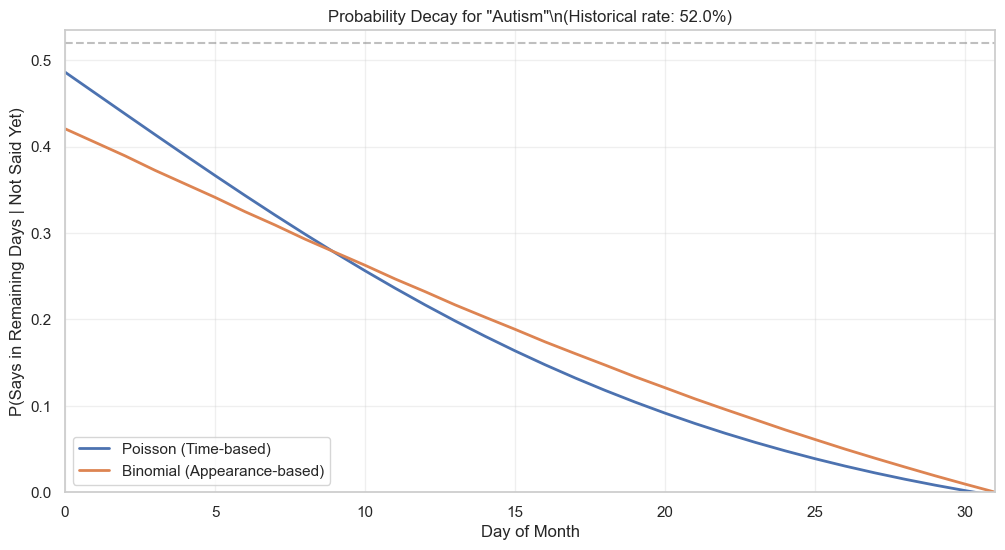

In [ ]:
import matplotlib.pyplot as plt

def plot_probability_decay(phrase_name, days_in_month=31):
    """
    Plot how probability changes as days pass without seeing the word.
    """
    phrase_monthly = monthly_stats[monthly_stats['phrase'] == phrase_name].iloc[0]
    phrase_appearance = appearance_stats[appearance_stats['phrase'] == phrase_name].iloc[0]
    
    days = np.arange(0, days_in_month + 1)
    poisson_probs = []
    binomial_probs = []
    
    for day in days:
        appearances = int(avg_appearances * (day / days_in_month))
        
        p_result = poisson_probability(
            phrase_monthly['monthly_rate'],
            phrase_monthly['avg_count_when_appeared'],
            day,
            days_in_month
        )
        
        b_result = binomial_probability(
            phrase_appearance['monthly_rate'],
            phrase_appearance['p_per_appearance'],
            appearances,
            avg_appearances,
            day,
            days_in_month
        )
        
        poisson_probs.append(p_result['p_remaining_bayesian'])
        binomial_probs.append(b_result['p_in_remaining_bayesian'])
    
    plt.figure(figsize=(12, 6))
    plt.plot(days, poisson_probs, label='Poisson (Time-based)', linewidth=2)
    plt.plot(days, binomial_probs, label='Binomial (Appearance-based)', linewidth=2)
    plt.xlabel('Day of Month')
    plt.ylabel('P(Says in Remaining Days | Not Said Yet)')
    plt.title(f'Probability Decay for "{phrase_name}"\\n(Historical rate: {phrase_monthly["monthly_rate"]:.1%})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, days_in_month)
    plt.ylim(0, max(max(poisson_probs), max(binomial_probs)) * 1.1)
    plt.axhline(y=phrase_monthly['monthly_rate'], color='gray', linestyle='--', alpha=0.5, label='Historical monthly rate')
    plt.show()

# Plot for a few different phrases
plot_phrases = ['Autism', 'Third Term', 'Whack Job']
for phrase in plot_phrases:
    if phrase in monthly_stats['phrase'].values:
        plot_probability_decay(phrase, DAYS_IN_MONTH)


### Summary Table: All Phrases for Current Day


In [ ]:
def generate_probability_table(day_of_month, days_in_month=31, appearances_so_far=None):
    """
    Generate a table of probabilities for all phrases.
    """
    if appearances_so_far is None:
        appearances_so_far = int(avg_appearances * (day_of_month / days_in_month))
    
    results = []
    
    for _, phrase_monthly in monthly_stats.iterrows():
        phrase_name = phrase_monthly['phrase']
        phrase_appearance = appearance_stats[appearance_stats['phrase'] == phrase_name].iloc[0]
        
        # Calculate probabilities
        poisson_probs = poisson_probability(
            phrase_monthly['monthly_rate'],
            phrase_monthly['avg_count_when_appeared'],
            day_of_month,
            days_in_month
        )
        
        binomial_probs = binomial_probability(
            phrase_appearance['monthly_rate'],
            phrase_appearance['p_per_appearance'],
            appearances_so_far,
            avg_appearances,
            day_of_month,
            days_in_month
        )
        
        # Choose recommended probability
        if phrase_monthly['monthly_rate'] < 0.2:
            recommended = poisson_probs['p_remaining_bayesian']
            model = 'Poisson'
        elif phrase_monthly['monthly_rate'] > 0.8:
            recommended = binomial_probs['p_in_remaining_bayesian']
            model = 'Binomial'
        else:
            recommended = (poisson_probs['p_remaining_bayesian'] + binomial_probs['p_in_remaining_bayesian']) / 2
            model = 'Average'
        
        results.append({
            'phrase': phrase_name,
            'historical_rate': phrase_monthly['monthly_rate'],
            'total_occurrences': phrase_monthly['total_occurrences'],
            'poisson_prob': poisson_probs['p_remaining_bayesian'],
            'binomial_prob': binomial_probs['p_in_remaining_bayesian'],
            'recommended_prob': recommended,
            'model_used': model
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('recommended_prob', ascending=False)
    
    return df_results

# Generate table
prob_table = generate_probability_table(CURRENT_DAY, DAYS_IN_MONTH)

print(f"\\n{'='*80}")
print(f"PROBABILITY TABLE FOR DAY {CURRENT_DAY} of {DAYS_IN_MONTH}")
print(f"Category: {CATEGORY_OF_INTEREST}")
print(f"{'='*80}\\n")

# Format for display
display_table = prob_table.copy()
display_table['historical_rate'] = display_table['historical_rate'].apply(lambda x: f"{x:.1%}")
display_table['poisson_prob'] = display_table['poisson_prob'].apply(lambda x: f"{x:.1%}")
display_table['binomial_prob'] = display_table['binomial_prob'].apply(lambda x: f"{x:.1%}")
display_table['recommended_prob'] = display_table['recommended_prob'].apply(lambda x: f"{x:.1%}")
display_table['total_occurrences'] = display_table['total_occurrences'].astype(int)

display(display_table)


\n================================================================================
PROBABILITY TABLE FOR DAY 13 of 31
Category: truth
================================================================================\n


/var/folders/mh/5p7rby_53kd1nj318h5rhkg80000gn/T/ipykernel_93891/1490028530.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  p_in_remaining_given_appears = 1 - np.exp(-lambda_daily * days_remaining) / (1 - np.exp(-lambda_daily * days_in_month))
/var/folders/mh/5p7rby_53kd1nj318h5rhkg80000gn/T/ipykernel_93891/1490028530.py:53: RuntimeWarning: invalid value encountered in scalar multiply
  p_remaining_bayesian = p_will_appear_given_not_seen * p_in_remaining_given_appears


,phrase,historical_rate,total_occurrences,poisson_prob,binomial_prob,recommended_prob,model_used
0,Transgender,100.0%,325,99.9%,99.6%,99.6%,Binomial
3,Predict / Prediction,96.0%,62,66.3%,64.3%,64.3%,Binomial
2,Sleepy Joe,96.0%,234,32.0%,62.5%,62.5%,Binomial
5,Windmill,88.0%,178,26.6%,55.6%,55.6%,Binomial
4,Pelosi,92.0%,168,39.9%,53.7%,53.7%,Binomial
6,Trump Derangement Syndrome,84.0%,86,47.6%,48.4%,48.4%,Binomial
1,DEI / Woke,96.0%,422,2.0%,46.6%,46.6%,Binomial
8,Newscum,80.0%,97,39.3%,41.9%,40.6%,Average
7,Barack Hussein Obama,80.0%,162,20.4%,34.4%,27.4%,Average
10,UFC,64.0%,86,25.4%,28.4%,26.9%,Average


### Key Insights

**Model Selection:**
- **Rare words (< 20% of months):** Use Poisson time-based model - better captures sporadic events
- **Common words (> 80% of months):** Use Binomial appearance-based model - activity level matters more than time
- **Moderate words:** Average both approaches

**Bayesian Updating:**
Both models implement Bayesian updates that account for not having seen the word yet. This is important because:
- If a word usually appears early and we haven't seen it, probability decreases
- The update assumes no intra-month pattern (uniform distribution)
- This prevents overfitting to spurious temporal patterns

**Practical Usage:**
1. Update `CURRENT_DAY` and `APPEARANCES_SO_FAR` with actual data
2. Use the interactive calculator for specific phrase lookups
3. Use the summary table for quick comparisons across all phrases
4. Check sensitivity plots to understand how probabilities evolve
